# DISRA Science Case Module

## THIS MODULE IS *NOT* COMPLETE

**NAME:** QSO_SURVEY

**GOAL:** What happens to the Circumgalactic Medium as massive galaxies quench and transform?

**OBJECTIVE:** Obtain QSO absorption-line measurements for > 100 massive galaxies in from z = 0.5-1.5.

**CODE PURPOSE:** Process the SDSS/GALEX QSO catalog to optimize the pathlength for z = 0.5 - 1.5 QSO absorbers. For now we are going to do this without any prior knowledge of foreground galaxies.

**BACKGROUND:**

Over the redshift interval z = 2 to 0.5, the fraction of massive galaxies (>10^10 Msun) that are star forming declines from $\gtrsim 100\%$ to $\lesssim 10\%$, a phenomenon known as `quenching'. This could be called the "epoch of galaxy transformation". Based on data collected at low redshift, we believe that the circumgalactic medium (CGM) of galaxies plays a large role in governing galaxy accretion, and is also the place where galactic feedback in the form of energetic outflows deposits energy and metals. But we do know very little about how the CGM participates in galaxy quenching -- whether it drives quenching by cutting off accretion, or whether it is a passive recipient of internal feedback. This program will use HWO's revolutionary UV capability to extend CGM observations from Hubble, which are limited to $z \lesssim 1$ by its sensitivity, into the $z > 1$ era when masssive galaxies are in their transformational phase. The figure of merit is pathlength per hour, which determines the number of galaxies whose CGM will be probed as a function of time.
	  
**MODIFICATION HISTORY:**

[2024-05-08] Started by JT in July 2024
[2025-11-07] Conversion to pyDRM framework by ARR

First we will do our basic imports.

In [42]:
from hwo_disra.api.notebook_api import DisraNBApi
from hwo_disra.Types import ScienceValue, Range, Time, DiscretePoints, SinglePoint

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from astropy.table import Table, vstack
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
#from syotools.wrappers.uvspec import uvspec_snr, uvspec_exptime
from syotools.wrappers.common import compute_observation

Now we read in a QSO catalog, from a qsocat/GALEX cross-match, filter out QSOs that are too faint or too low in redshift, and plot the distribution of QSO FUV mags vs. redshift to get a sense of the distribution of background sources. The QSO catalog is bundled with hwotools in the "data" subdirectory.

In [43]:
qsocat = Table.read('dr7qso_galex.fits')
qsocat = qsocat['SDSSNAME', 'RA', 'DEC', 'Z', 'PSFMAG_G', 'PSFMAGERR_G', 'FUV_MAG', 'NUV_MAG']
qsocat['gal_pathlength'] = qsocat['Z'] - 0.5 - 0.1
qsocat['gal_pathlength'][qsocat['gal_pathlength'] < 0.] = 0.

We will now filter the QSO catalog for z < 2 and FUV_MAG < 20, and plot it.

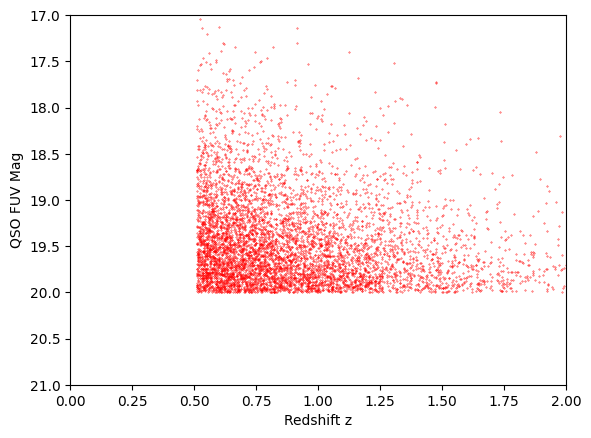

In [44]:
qsocat = qsocat[qsocat['FUV_MAG'] > 0.]
qsocat = qsocat[qsocat['FUV_MAG'] < 20.]
qsocat = qsocat[qsocat['Z'] < 2.]
qsocat = qsocat[qsocat['Z'] > 0.51]
plot = True
if plot:
    plt.scatter(qsocat['Z'], qsocat['FUV_MAG'], marker='o', s=0.1, color='red')
    qsocat.sort('FUV_MAG')
    plt.ylim(21,17)
    plt.xlim(0, 2.)
    plt.xlabel('Redshift z')
    _ = plt.ylabel('QSO FUV Mag')

Now we will write a function that calls the SYOTools uvspec_exptime wrapper around the UVI ETC. To save time, because there are so many QSOs, we will not compute the unique SNR/exptime for each one. Rather, we will compute the values for a small set of magnitudes and then interpolate the exptime for each individual QSO from this curve.

In [45]:
# Not certain what the correct bin edges are yet, these are placeholders
redshiftbins= np.array((0.75,1.0,1.25,1.5,1.75,2.0,2.25))
magbins = np.array((16.5,17,17.5,18,18.5,19.0,19.5,20.0))

def create_bins():
    # the structure is a dict of cells, for addressing reasons
    binned_data = {}
    for x in redshiftbins:
        for y in magbins:
            binned_data[f"{x}_{y}"] = Table(names=("SDSSNAME", "RA", "DEC", "Z", "PSFMAG_G", "PSFMAGERR_G", "FUV_MAG", "NUV_MAG", "gal_pathlength"),
                                           dtype=(bytes, float, float, float, float, float, float, float, float)
            )

    return binned_data

In [46]:
def fill_bins(qsocat, binned_data):
    """
    Input is the catalog, and the dictionary structure to fill.
    """
    
    for entry in qsocat:
        redidx = np.digitize(entry['Z'], redshiftbins)
        magidx = np.digitize(entry['FUV_MAG'], magbins)
        binned_data[f"{redshiftbins[redidx]}_{magbins[magidx]}"] = vstack([binned_data[f"{redshiftbins[redidx]}_{magbins[magidx]}"], entry])
    return binned_data

In [47]:
def select_samples(binned_table, samples):
    #print(samples, len(binned_table))
    if len(binned_table) <= samples:
        return_table = binned_table
    else:
        binned_table.sort("gal_pathlength", reverse=True) # get the longest pathlengths first
        #print(sortorder[0:samples])
        return_table = binned_table[0:samples]
    return return_table

In [48]:
api = DisraNBApi()
binned_data = create_bins()
binned_data = fill_bins(qsocat, binned_data)

def compute_yield(binned_data, samples):


    #print(binned_data)
    
    selection = Table(names=("SDSSNAME", "RA", "DEC", "Z", "PSFMAG_G", "PSFMAGERR_G", "FUV_MAG", "NUV_MAG", "gal_pathlength"),
                                           dtype=(bytes, float, float, float, float, float, float, float, float)
                     )
    for cell in binned_data:
        #print(samples, cell, len(binned_data[cell]))
        selection = vstack((selection, select_samples(binned_data[cell], int(samples))))
    pathlength = np.sum(selection["gal_pathlength"])
    return selection

yielder = api.yieldinator(name="QSO",
                          thresholds = {ScienceValue.ENABLING: 3, ScienceValue.STATE_OF_THE_ART: 1, 
                                        ScienceValue.ENHANCING: 2, ScienceValue.BREAKTHROUGH: 4}, 
                          variables = {"binned_data": SinglePoint(binned_data, 'bins'), "samples": Range(1,5, 'samples')},
                          yield_function = compute_yield)

yield_results = api.evaluate(yielder, steps=5)

In [49]:

exp_time_at_snr = api.exptime_from_magnitude_fun(snr_goal=10, template="Flat (AB)", bandpass="galex,fuv")
def compute_time(eac, yield_value, binned_data, samples) -> Time:
     # TODO: Once we're on the SEI yaml read this from there.
    camera_fov = (2.0*3.0)/(60*60.)   # HRI field-of-view in sq. deg.

    total_exposure_time = 0
    exptime = []
    
    for star in yield_value:
        exposure_time = exp_time_at_snr(eac, star["FUV_MAG"])
        exptime.append(exposure_time)   
        total_exposure_time += exposure_time
    yield_value[f"{eac.name}_exptime_{int(samples)}"] = exptime
    
    return Time(exposure_time)

Now call this function six time to get exposure times for SNR = 10 and 20 for each QSO added to the catalog table. We will do this for all three EACs.

In [50]:
timeinator = api.timeinator(yielder, timeinate=compute_time)

evaluations = api.evaluate(timeinator, steps = 5, register=True)

In [51]:
print(evaluations[0])

YieldEvaluation(sample_points=[YieldSample(yield_result=<Table length=33>
     SDSSNAME              RA         ...    EAC1_exptime_1   
     bytes18            float64       ...       float64       
------------------ ------------------ ... --------------------
091217.74+245037.9 138.07394409179688 ...  0.04265558603899625
100102.55+594414.3 150.26063537597656 ...  0.06686822089783193
114552.18+620633.6  176.4674530029297 ...  0.11250676710934181
232214.72-103725.1  350.5613708496094 ...  0.13281408996673089
114610.51+164946.1 176.54380798339844 ...  0.23372080332484815
104923.24+021806.0 162.34683227539062 ...  0.33521297744030054
134858.32+545014.2 207.24302673339844 ...   0.6139900641135898
134719.40+590232.7  206.8308563232422 ... 0.029186937194868427
075112.30+291938.3 117.80128479003906 ...  0.05280975354223602
               ...                ... ...                  ...
151507.99+072345.9  228.7833251953125 ...   0.3823292095171561
130437.91+474107.0 196.15797424316406 ...   

In [52]:
color = np.asarray((1, 0.75, 0))
def plot_yield(evaluations, num):
    fig = plt.figure(figsize=(16,9))
    axes = [fig.add_subplot(2, 5, x+1) for x in range(10)]
    for points,subnum in zip(evaluations[num].sample_points, np.arange(0,5)):
        sampletable = points.yield_result
        
        axes[subnum].scatter(sampletable['Z'], sampletable['FUV_MAG'], marker='o', s=0.1, color='red')
        sampletable.sort('FUV_MAG')
        axes[subnum].set_ylim(21,17)
        axes[subnum].set_xlim(0, 2.5)
        axes[subnum].set_xlabel('Redshift z')
        _ = axes[subnum].set_ylabel('QSO FUV Mag')
        axes[subnum].set_title(f"{subnum+1} QSOs ({len(sampletable)} total)")

        cum_length = np.asarray(np.cumsum(sampletable["gal_pathlength"]))
        cum_time = np.asarray(np.cumsum(sampletable[f"{evaluations[num].eac}_exptime_{subnum+1}"]))

        xdata = np.concatenate(([cum_time[0]], cum_time, [cum_time[-1]]))
        ydata = np.concatenate(([0], cum_length, [0]))
        poly = Polygon(list(zip(xdata,ydata)), closed=True)
        patch = PatchCollection([poly], color=np.append(color, 0.5))
        axes[subnum+5].add_collection(patch)
        
        #axes[subnum+5].scatter(sampletable[f"{evaluations[num].eac}_exptime_{subnum+1}"], sampletable["gal_pathlength"], color=np.append(color,1))
        axes[subnum+5].plot(cum_time, cum_length, color=np.append(color,1))
        axes[subnum+5].bar(cum_time,sampletable["gal_pathlength"])
        
        axes[subnum+5].set_xlabel("Time (hr)")
        _ = axes[subnum+5].set_ylabel("Pathlength")
        axes[subnum+5].set_title(f"Time: {cum_time[-1]:.2f} hr, Path {cum_length[-1]:.2f}")
    
    plt.suptitle(evaluations[num].eac)
    
    plt.tight_layout()

Print out the first few lines of the table to ensure things make sense.

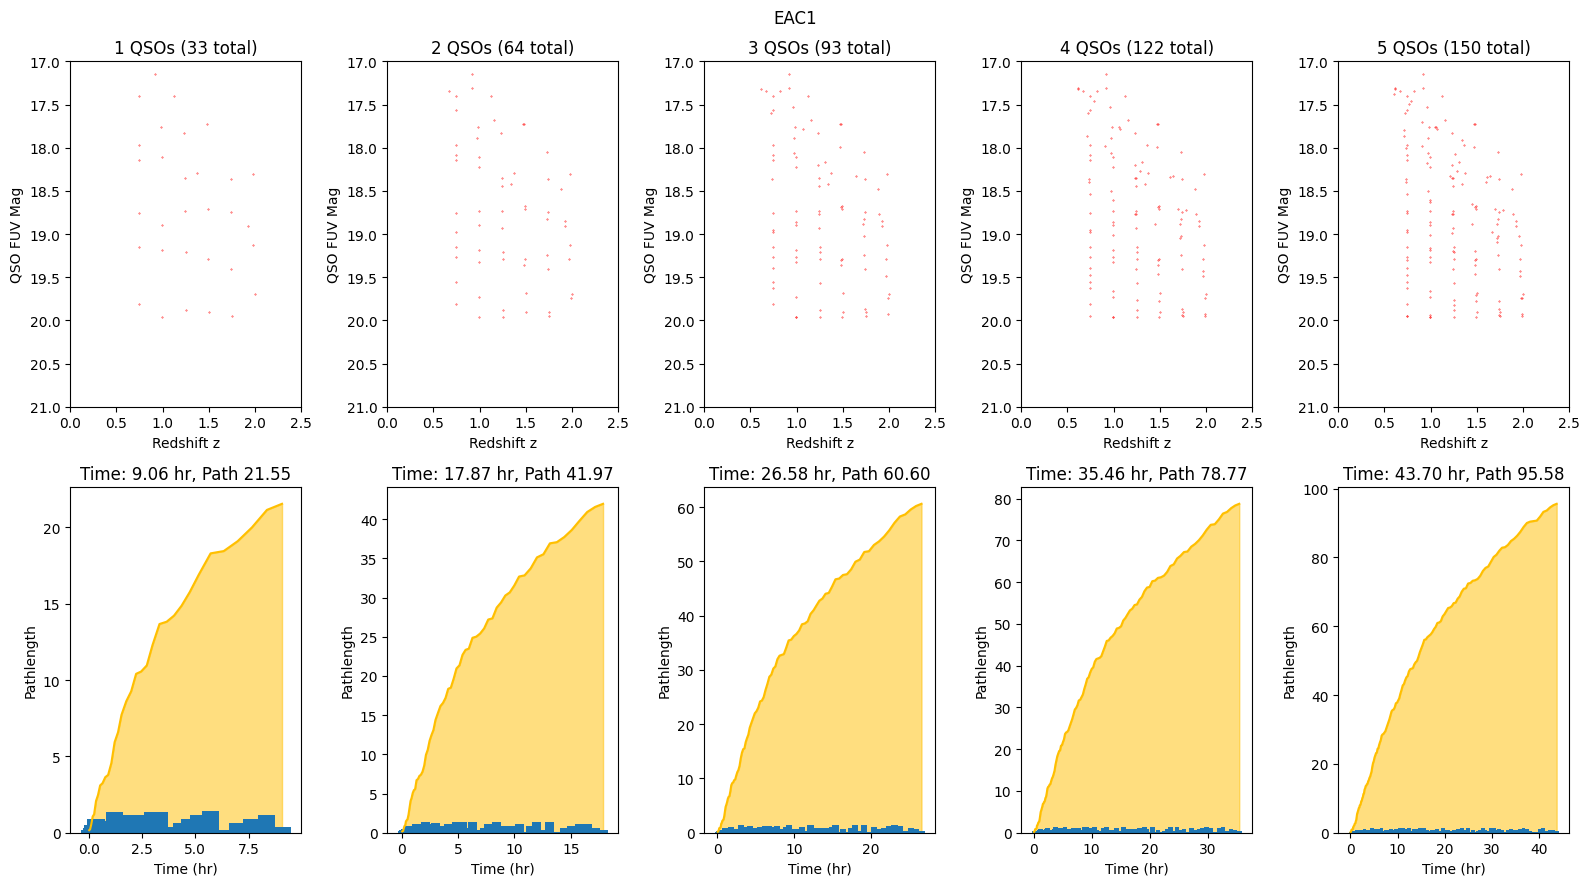

In [53]:
plot_yield(evaluations, 0)

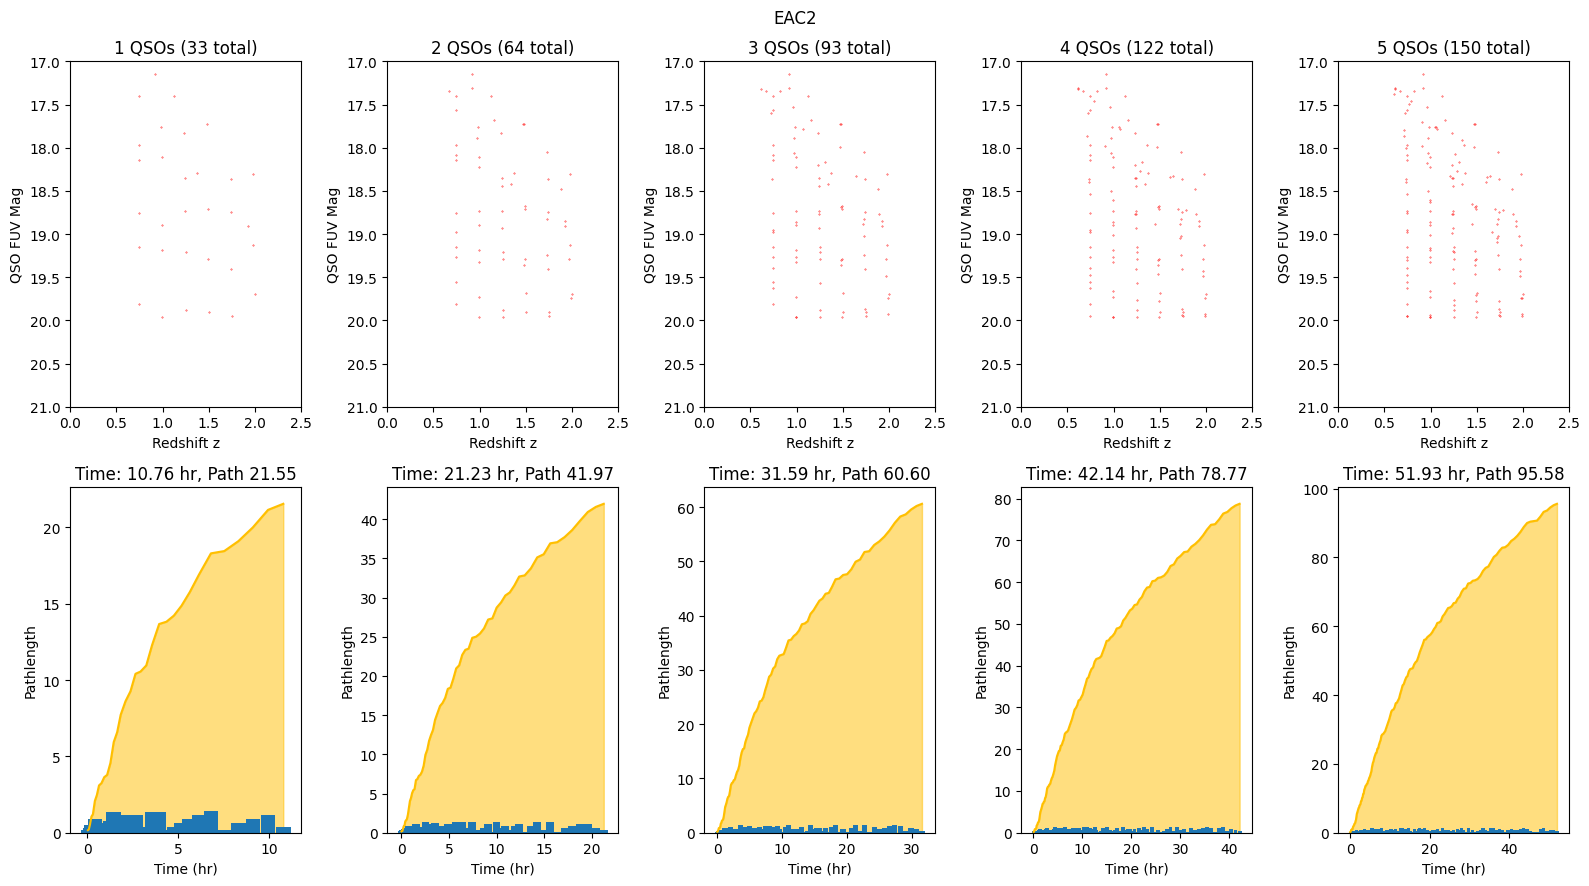

In [54]:
plot_yield(evaluations, 1)

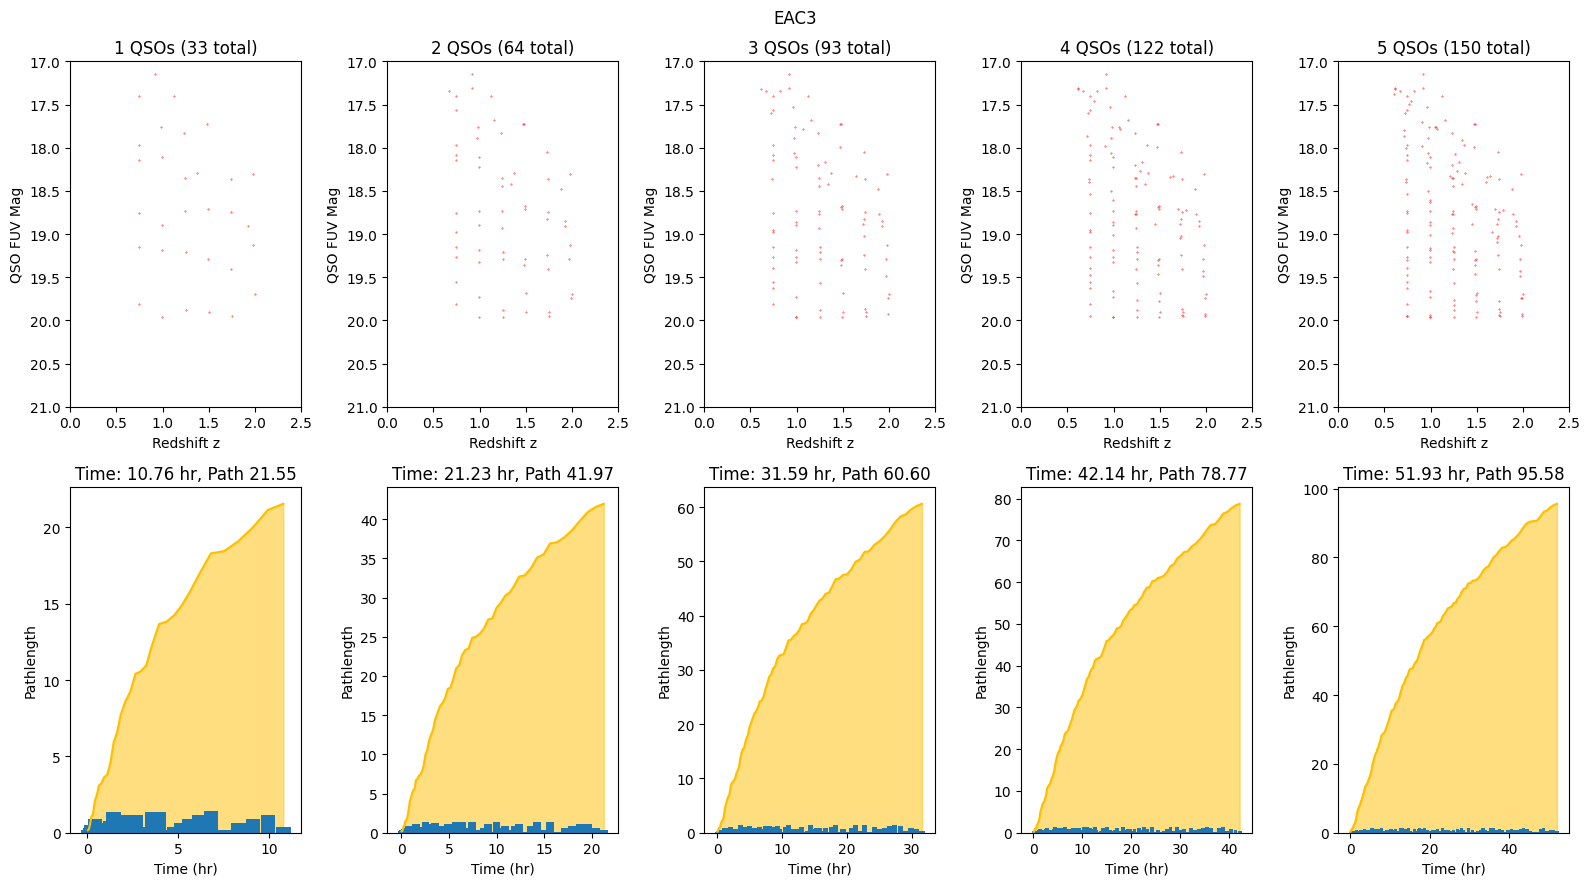

In [55]:
plot_yield(evaluations, 2)